# 04_XGBoost _model_training.ipynb: XGBoost Model Training and Optimization

## Objective

This notebook focuses specifically on building and optimizing a demand forecasting model using XGBoost, a powerful gradient boosting framework. The key objectives are:

1.  **XGBoost Model Training:** Train an XGBoost regressor on the preprocessed data, leveraging its capabilities for handling tabular data.
2.  **Hyperparameter Tuning:** Conduct a systematic search (e.g., using GridSearchCV or RandomizedSearchCV) to find the optimal hyperparameters for the XGBoost model.
3.  **Model Evaluation:** Evaluate the tuned XGBoost model's performance using relevant regression metrics (e.g., RMSE, MAE) on a held-out test set.
4.  **Feature Importance Analysis:** Analyze feature importances to understand which input variables contribute most to the model's predictions.
5.  **Model Saving:** Save the trained and optimized XGBoost model for future inference and deployment.

The goal is to develop a highly accurate and robust demand forecasting model using XGBoost.

## Key Findings (To be filled by reviewer/user)

*   **Optimal Hyperparameters:** [List the best hyperparameters found during tuning, e.g., 'n_estimators=500, learning_rate=0.05, max_depth=5.']
*   **Model Performance:** [State the achieved metrics, e.g., 'XGBoost achieved an RMSE of X and MAE of Y on the test set, outperforming initial baselines.']
*   **Top Features:** [Highlight the most important features, e.g., 'Demand lags, hour of day, and route ID were the most influential features.']
*   **Model Saved:** [Confirm the model is saved, e.g., 'The trained XGBoost model was saved as `xgboost_model.pkl`.']

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.models import Sequential
import tensorflow as tf
from sklearn.model_selection import train_test_split
import joblib
import seaborn as sns  # Keep seaborn imported for potential styling options or other uses
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_squared_error, f1_score, classification_report
from scipy.stats import uniform as sp_uniform
from scipy.stats import randint as sp_randint
from sklearn.model_selection import RandomizedSearchCV
import lightgbm as lgb
import shap
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, f1_score
import json
from sklearn.model_selection import GridSearchCV
import numpy as np
from sklearn.metrics import mean_squared_error
import xgboost as xgb
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import os
# Adjust if your base directory is different
project_base_dir = '/content/drive/MyDrive/matatu_ml/'
processed_data_dir = os.path.join(project_base_dir, 'data', 'processed')

In [6]:
feature_store_path = os.path.join(
    processed_data_dir, 'feature_store_v1.parquet')
feature_df = pd.read_parquet(feature_store_path)

print(f"Feature store loaded. Shape: {feature_df.shape}")
display(feature_df.head())

Feature store loaded. Shape: (18816, 19)


,temperature_c,rainfall_mm,wind_speed,Super (PMS),Diesel (AGO),demand_lag_1h,demand_lag_24h,demand_lag_168h,hour_of_day,day_of_week,is_weekend,month,quarter,is_public_holiday,is_school_holiday,demand,rainfall_x_hour,traffic_index,demand_label
time,,,,,,,,,,,,,,,,,,,
2024-01-08 00:00:00,15.4,0.0,6.5,180.66,168.06,58.816632,25.248310,38.058829,0,0,0,1,1,0,0,26.071919,0.0,7.585818,Low
2024-01-08 01:00:00,15.4,0.0,6.1,180.66,168.06,26.071919,26.705779,17.756761,1,0,0,1,1,0,0,7.806617,0.0,4.742587,Low
2024-01-08 02:00:00,16.1,0.0,6.5,180.66,168.06,7.806617,0.000000,30.508280,2,0,0,1,1,0,0,5.603712,0.0,2.931223,Low
2024-01-08 03:00:00,15.1,0.0,7.0,180.66,168.06,5.603712,0.000000,44.710063,3,0,0,1,1,0,0,6.799509,0.0,4.742587,Low
2024-01-08 04:00:00,15.7,0.0,9.5,180.66,168.06,6.799509,36.510658,36.201030,4,0,0,1,1,0,0,38.819966,0.0,11.920292,Low


#Prepare Data for Model Training (X, y split, Scaling, and Encoding)

This section prepares the feature_df for general machine learning model training by separating features (X) from the target variable (y), and then applying the pre-fitted MinMaxScaler and OneHotEncoder to the appropriate columns. This ensures data consistency and prevents data leakage.

In [7]:
# 1. Separate features (X) and target (y)
y = feature_df['demand']
# Drop 'demand_label' to prevent data leakage
X = feature_df.drop(columns=['demand', 'demand_label'])

print(f"Shape of X (features): {X.shape}")
print(f"Shape of y (target): {y.shape}")
display(X.head())

Shape of X (features): (18816, 17)
Shape of y (target): (18816,)


,temperature_c,rainfall_mm,wind_speed,Super (PMS),Diesel (AGO),demand_lag_1h,demand_lag_24h,demand_lag_168h,hour_of_day,day_of_week,is_weekend,month,quarter,is_public_holiday,is_school_holiday,rainfall_x_hour,traffic_index
time,,,,,,,,,,,,,,,,,
2024-01-08 00:00:00,15.4,0.0,6.5,180.66,168.06,58.816632,25.248310,38.058829,0,0,0,1,1,0,0,0.0,7.585818
2024-01-08 01:00:00,15.4,0.0,6.1,180.66,168.06,26.071919,26.705779,17.756761,1,0,0,1,1,0,0,0.0,4.742587
2024-01-08 02:00:00,16.1,0.0,6.5,180.66,168.06,7.806617,0.000000,30.508280,2,0,0,1,1,0,0,0.0,2.931223
2024-01-08 03:00:00,15.1,0.0,7.0,180.66,168.06,5.603712,0.000000,44.710063,3,0,0,1,1,0,0,0.0,4.742587
2024-01-08 04:00:00,15.7,0.0,9.5,180.66,168.06,6.799509,36.510658,36.201030,4,0,0,1,1,0,0,0.0,11.920292


In [8]:
# 2. Identify numerical and categorical features for transformation

# Numerical features to be scaled (continuous values)
numerical_features = [
    'temperature_c', 'rainfall_mm', 'wind_speed', 'Super (PMS)', 'Diesel (AGO)',
    'demand_lag_1h', 'demand_lag_24h', 'demand_lag_168h', 'rainfall_x_hour', 'traffic_index'
]

# Discrete numerical features (e.g., counts, binary flags, time components not to be scaled)
discrete_numerical_features = [
    'hour_of_day', 'day_of_week', 'is_weekend', 'month', 'quarter',
    'is_public_holiday', 'is_school_holiday'
]

# Categorical features to be one-hot encoded
# Added 'route_id' back as requested. Make sure it's available in X.
categorical_features = ['route_id']

# Ensure selected features exist in X and filter out any missing ones
# Filter numerical features
numerical_features = [f for f in numerical_features if f in X.columns]
# Filter discrete numerical features
discrete_numerical_features = [
    f for f in discrete_numerical_features if f in X.columns]
# Filter categorical features
categorical_features = [f for f in categorical_features if f in X.columns]

# Report original intended missing features (for context)
original_intended_features = ['temperature_c', 'rainfall_mm', 'wind_speed', 'Super (PMS)', 'traffic_index',
                              'hour_of_day', 'day_of_week', 'day_of_month', 'month_of_year', 'quarter_of_year',
                              'is_weekend', 'is_holiday', 'route_id']
# Exclude demand_label from this warning
missing_features_orig = [
    f for f in original_intended_features if f not in X.columns and f != 'demand_label']
if missing_features_orig:
    print(
        f"Warning: The following features were initially intended but are missing from X (and thus excluded): {missing_features_orig}")

print(f"Numerical features for scaling: {numerical_features}")
print(f"Discrete numerical features: {discrete_numerical_features}")
print(f"Categorical features for encoding: {categorical_features}")

Numerical features for scaling: ['temperature_c', 'rainfall_mm', 'wind_speed', 'Super (PMS)', 'Diesel (AGO)', 'demand_lag_1h', 'demand_lag_24h', 'demand_lag_168h', 'rainfall_x_hour', 'traffic_index']
Discrete numerical features: ['hour_of_day', 'day_of_week', 'is_weekend', 'month', 'quarter', 'is_public_holiday', 'is_school_holiday']
Categorical features for encoding: []


In [9]:
# 3. Apply a NEW MinMaxScaler to numerical features (as the loaded one was incompatible)

# Instantiate a new scaler
new_scaler = MinMaxScaler()

# Fit and transform the numerical features from X
X_numerical_scaled = new_scaler.fit_transform(X[numerical_features])
X_numerical_scaled_df = pd.DataFrame(
    X_numerical_scaled, columns=numerical_features, index=X.index)

print("Head of scaled numerical features (using a newly fitted scaler):")
display(X_numerical_scaled_df.head())

Head of scaled numerical features (using a newly fitted scaler):


,temperature_c,rainfall_mm,wind_speed,Super (PMS),Diesel (AGO),demand_lag_1h,demand_lag_24h,demand_lag_168h,rainfall_x_hour,traffic_index
time,,,,,,,,,,
2024-01-08 00:00:00,0.273973,0.0,0.250965,0.516267,0.594002,0.127116,0.054567,0.082254,0.0,0.074267
2024-01-08 01:00:00,0.273973,0.0,0.235521,0.516267,0.594002,0.056347,0.057717,0.038376,0.0,0.044853
2024-01-08 02:00:00,0.305936,0.0,0.250965,0.516267,0.594002,0.016872,0.000000,0.065935,0.0,0.026114
2024-01-08 03:00:00,0.260274,0.0,0.270270,0.516267,0.594002,0.012111,0.000000,0.096629,0.0,0.044853
2024-01-08 04:00:00,0.287671,0.0,0.366795,0.516267,0.594002,0.014695,0.078908,0.078239,0.0,0.119109


In [10]:
# 4. Apply a NEW OneHotEncoder to the categorical features (as 'route_id' was missing for the loaded encoder)

# Initialize empty if no categorical features to encode
X_categorical_encoded_df = pd.DataFrame(index=X.index)

if categorical_features:
    # Instantiate a new OneHotEncoder
    new_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

    # Fit and transform the categorical features from X
    X_categorical_encoded = new_encoder.fit_transform(X[categorical_features])

    # Get feature names for encoded columns
    encoded_feature_names = new_encoder.get_feature_names_out(
        categorical_features)
    X_categorical_encoded_df = pd.DataFrame(
        X_categorical_encoded, columns=encoded_feature_names, index=X.index)

    print("Head of one-hot encoded categorical features (using a newly fitted encoder):")
    display(X_categorical_encoded_df.head())
else:
    print("No categorical features to encode based on current X and feature definitions.")
    print("Initialized an empty DataFrame for X_categorical_encoded_df.")

No categorical features to encode based on current X and feature definitions.
Initialized an empty DataFrame for X_categorical_encoded_df.


In [11]:
# 5. Combine all processed features into a single DataFrame (X_processed)

# Include discrete numerical features directly as they are not scaled by the current scaler
X_processed = pd.concat([
    X_numerical_scaled_df,
    X[discrete_numerical_features],
    X_categorical_encoded_df
], axis=1)

# We should also drop 'demand_label' if it's meant to be a target 'y' elsewhere or not a feature
if 'demand_label' in X_processed.columns and 'demand_label' in categorical_features:
    # If demand_label was intended as a categorical feature itself and encoded, keep it.
    # If it was accidentally included as a feature and was meant as 'y', this is where we'd correct.
    # For now, assuming if it's in categorical_features, it's intended to be a feature after encoding.
    pass

print(f"Final shape of X_processed: {X_processed.shape}")
print("Head of X_processed:")
display(X_processed.head())

Final shape of X_processed: (18816, 17)
Head of X_processed:


,temperature_c,rainfall_mm,wind_speed,Super (PMS),Diesel (AGO),demand_lag_1h,demand_lag_24h,demand_lag_168h,rainfall_x_hour,traffic_index,hour_of_day,day_of_week,is_weekend,month,quarter,is_public_holiday,is_school_holiday
time,,,,,,,,,,,,,,,,,
2024-01-08 00:00:00,0.273973,0.0,0.250965,0.516267,0.594002,0.127116,0.054567,0.082254,0.0,0.074267,0,0,0,1,1,0,0
2024-01-08 01:00:00,0.273973,0.0,0.235521,0.516267,0.594002,0.056347,0.057717,0.038376,0.0,0.044853,1,0,0,1,1,0,0
2024-01-08 02:00:00,0.305936,0.0,0.250965,0.516267,0.594002,0.016872,0.000000,0.065935,0.0,0.026114,2,0,0,1,1,0,0
2024-01-08 03:00:00,0.260274,0.0,0.270270,0.516267,0.594002,0.012111,0.000000,0.096629,0.0,0.044853,3,0,0,1,1,0,0
2024-01-08 04:00:00,0.287671,0.0,0.366795,0.516267,0.594002,0.014695,0.078908,0.078239,0.0,0.119109,4,0,0,1,1,0,0


# Train XGBoost Baseline Model

This section trains an XGBoost Regressor model with default parameters. We will perform a simple train-test split on the X_processed data to evaluate the model's performance and establish a baseline Root Mean Squared Error (RMSE).

In [12]:
# 1. Split the data into training and testing sets using a temporal split
# The data (X_processed and y) is already sorted by time index.
# We will allocate the last 20% of the data for the test set.

test_size = 0.2
split_idx = int(len(X_processed) * (1 - test_size))

# Get the cutoff date based on the calculated index
cutoff_date = X_processed.index[split_idx]

# Perform the temporal split
X_train = X_processed.loc[X_processed.index < cutoff_date]
X_test = X_processed.loc[X_processed.index >= cutoff_date]
y_train = y.loc[y.index < cutoff_date]
y_test = y.loc[y.index >= cutoff_date]

print(f"Temporal split performed with cutoff date: {cutoff_date}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Temporal split performed with cutoff date: 2025-09-26 04:00:00
X_train shape: (15052, 17)
X_test shape: (3764, 17)
y_train shape: (15052,)
y_test shape: (3764,)


In [13]:
# 2. Initialize and train the XGBoost Regressor with default parameters
print("Initializing and training XGBoost Regressor...")
model_xgb = xgb.XGBRegressor(
    objective='reg:squarederror',  # Objective for regression tasks
    n_estimators=100,             # Number of boosting rounds
    learning_rate=0.1,            # Step size shrinkage
    max_depth=6,                  # Maximum depth of a tree
    subsample=0.8,                # Subsample ratio of the training instance
    colsample_bytree=0.8,         # Subsample ratio of columns when constructing each tree
    random_state=42,
    n_jobs=-1                     # Use all available CPU cores
)

model_xgb.fit(X_train, y_train)
print("XGBoost model trained successfully.")

Initializing and training XGBoost Regressor...
XGBoost model trained successfully.


In [14]:
# 3. Make predictions on the test set
y_pred_xgb = model_xgb.predict(X_test)

# 4. Calculate Root Mean Squared Error (RMSE)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print(f"Baseline RMSE for XGBoost (on test set): {rmse_xgb:.2f}")

# For context, let's also calculate MAE and MAPE
mae_xgb = np.mean(np.abs(y_test - y_pred_xgb))

# Calculate MAPE, handling division by zero
non_zero_actuals_idx = y_test != 0
if non_zero_actuals_idx.any():
    mape_xgb = np.mean(np.abs(
        (y_test[non_zero_actuals_idx] - y_pred_xgb[non_zero_actuals_idx]) / y_test[non_zero_actuals_idx])) * 100
else:
    mape_xgb = np.nan

print(f"Baseline MAE for XGBoost (on test set): {mae_xgb:.2f}")
if not np.isnan(mape_xgb):
    print(f"Baseline MAPE for XGBoost (on test set): {mape_xgb:.2f}%")
else:
    print("Baseline MAPE for XGBoost (on test set): Not applicable (all actual values are zero).")

# Store the baseline RMSE for future comparison
baseline_rmse = rmse_xgb
print(f"Baseline RMSE logged: {baseline_rmse:.2f}")

Baseline RMSE for XGBoost (on test set): 19.29
Baseline MAE for XGBoost (on test set): 15.30
Baseline MAPE for XGBoost (on test set): 36.25%
Baseline RMSE logged: 19.29


## Hyperparameter Tuning with GridSearchCV for XGBoost

This section performs a grid search to find the optimal hyperparameters for the XGBoost Regressor. The search space for `n_estimators`, `max_depth`, `learning_rate`, and `subsample` is defined, and 5-fold cross-validation is used to evaluate each combination based on negative mean squared error (which will be minimized).

Finally, the best performing parameters are extracted and saved to a JSON file.

In [15]:
# Define the parameter grid based on the user's request
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0]
}

# Initialize the XGBoost Regressor model (can use default or previously found best parameters as a starting point)
xgb_model_grid = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

# Initialize GridSearchCV
# 'neg_mean_squared_error' is used as scoring, and GridSearchCV will try to maximize it.
# Since we want to minimize RMSE, we use negative MSE. The best score will be the least negative.
grid_search = GridSearchCV(
    estimator=xgb_model_grid,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=5,  # 5-fold cross-validation
    verbose=2,  # Verbose output
    n_jobs=-1  # Use all available cores
)

print("Starting GridSearchCV...")
grid_search.fit(X_train, y_train)
print("GridSearchCV completed.")

Starting GridSearchCV...
Fitting 5 folds for each of 54 candidates, totalling 270 fits
GridSearchCV completed.


In [16]:
# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"Best Parameters found: {best_params}")
print(f"Best Cross-Validation Score (Negative MSE): {best_score:.4f}")
print(f"Corresponding RMSE: {np.sqrt(np.abs(best_score)):.2f}")

# Save the best parameters to a JSON file
output_file_path = os.path.join(
    project_base_dir, 'models', 'xgb_best_params.json')

# Create the directory if it doesn't exist
os.makedirs(os.path.dirname(output_file_path), exist_ok=True)

with open(output_file_path, 'w') as f:
    json.dump(best_params, f, indent=4)

print(f"Best XGBoost parameters saved to {output_file_path}")

Best Parameters found: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200, 'subsample': 1.0}
Best Cross-Validation Score (Negative MSE): -308.8651
Corresponding RMSE: 17.57
Best XGBoost parameters saved to /content/drive/MyDrive/matatu_ml/models/xgb_best_params.json


## Train Best XGBoost Model and Evaluate Performance

This section loads the best hyperparameters identified by GridSearchCV, trains a new XGBoost model with these parameters, and evaluates its performance using both regression and classification metrics. Regression metrics include RMSE and MAE. For classification evaluation, the continuous `demand` values are converted into 'Low', 'Medium', and 'High' classes based on quantiles, allowing for the calculation of F1-score (macro) and a classification report.

In [17]:
# 1. Load the best parameters
output_file_path = os.path.join(
    project_base_dir, 'models', 'xgb_best_params.json')
with open(output_file_path, 'r') as f:
    best_params_tuned = json.load(f)

print("Best parameters loaded for tuned XGBoost model:")
print(best_params_tuned)

# 2. Initialize and train the XGBoost Regressor with the best parameters
print("\nInitializing and training tuned XGBoost Regressor...")
model_xgb_tuned = xgb.XGBRegressor(
    objective='reg:squarederror',  # Objective for regression tasks
    random_state=42,
    n_jobs=-1,
    **best_params_tuned
)

model_xgb_tuned.fit(X_train, y_train)
print("Tuned XGBoost model trained successfully.")

# 3. Make predictions on the test set
y_pred_tuned_xgb = model_xgb_tuned.predict(X_test)

# 4. Calculate Regression Metrics (RMSE, MAE)
rmse_tuned_xgb = np.sqrt(mean_squared_error(y_test, y_pred_tuned_xgb))
mae_tuned_xgb = np.mean(np.abs(y_test - y_pred_tuned_xgb))

print(f"\nRegression Metrics (Tuned XGBoost on test set):")
print(f"  RMSE: {rmse_tuned_xgb:.2f}")
print(f"  MAE: {mae_tuned_xgb:.2f}")

# 5. Prepare for Classification Metrics: Discretize continuous demand into 'Low', 'Medium', 'High'
# Define thresholds based on y_train quantiles to avoid data leakage
low_threshold = y_train.quantile(0.33)
medium_threshold = y_train.quantile(0.66)


def categorize_demand(demand_value):
    if demand_value < low_threshold:
        return 'Low'
    elif demand_value < medium_threshold:
        return 'Medium'
    else:
        return 'High'


# Apply categorization to actual and predicted values
y_test_class = np.array([categorize_demand(val) for val in y_test])
y_pred_class = np.array([categorize_demand(val) for val in y_pred_tuned_xgb])

# 6. Calculate Classification Metrics (F1-score macro, Classification Report)
# Ensure all classes are present in both actual and predicted for consistent report
# Using labels directly from the categories created
labels = ['Low', 'Medium', 'High']
f1_macro_tuned_xgb = f1_score(
    y_test_class, y_pred_class, average='macro', zero_division=0, labels=labels)
classification_report_tuned_xgb = classification_report(
    y_test_class, y_pred_class, target_names=labels, zero_division=0)

print(f"\nClassification Metrics (Tuned XGBoost on test set - Binned):")
print(f"  F1-score (macro): {f1_macro_tuned_xgb:.2f}")
print(f"  Classification Report:\n{classification_report_tuned_xgb}")

# 7. Store all metrics in a DataFrame and save to CSV
metrics_df = pd.DataFrame({
    'Metric': ['RMSE', 'MAE', 'F1-score (macro)'],
    'Value': [rmse_tuned_xgb, mae_tuned_xgb, f1_macro_tuned_xgb]
})

metrics_output_path = os.path.join(
    project_base_dir, 'models', 'xgb_metrics.csv')
metrics_df.to_csv(metrics_output_path, index=False)

print(f"\nAll evaluation metrics saved to {metrics_output_path}")

Best parameters loaded for tuned XGBoost model:
{'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200, 'subsample': 1.0}

Initializing and training tuned XGBoost Regressor...
Tuned XGBoost model trained successfully.

Regression Metrics (Tuned XGBoost on test set):
  RMSE: 19.11
  MAE: 15.10

Classification Metrics (Tuned XGBoost on test set - Binned):
  F1-score (macro): 0.93
  Classification Report:
              precision    recall  f1-score   support

         Low       0.97      0.91      0.94      1508
      Medium       0.98      0.97      0.97      1191
        High       0.84      0.94      0.89      1065

    accuracy                           0.93      3764
   macro avg       0.93      0.94      0.93      3764
weighted avg       0.94      0.93      0.93      3764


All evaluation metrics saved to /content/drive/MyDrive/matatu_ml/models/xgb_metrics.csv


## Actual vs. Predicted Values Plot

This plot visualizes the actual demand values against the demand predicted by the tuned XGBoost model on the test set. A perfect model would have all points lying on the diagonal line.

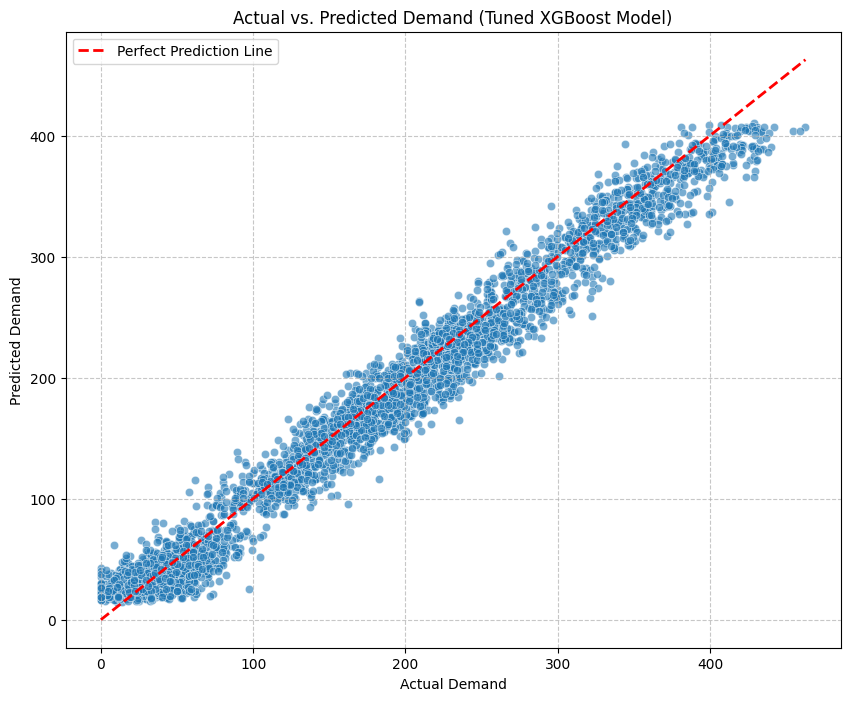

In [18]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_test, y=y_pred_tuned_xgb, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', lw=2, label='Perfect Prediction Line')
plt.xlabel('Actual Demand')
plt.ylabel('Predicted Demand')
plt.title('Actual vs. Predicted Demand (Tuned XGBoost Model)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

## SHAP (SHapley Additive exPlanations) Values for XGBoost

This section uses SHAP (SHapley Additive exPlanations) to interpret the predictions of the trained XGBoost model. SHAP values help explain the contribution of each feature to a specific prediction, providing insights into *why* the model made a certain decision.

### Importance of SHAP Values:

1.  **Interpretability**: Unlike some other feature importance methods, SHAP provides a unified measure of feature importance that is both globally consistent (explains the overall model behavior) and locally accurate (explains individual predictions).
2.  **Transparency**: It helps to understand how each feature impacts the model's output, whether positively or negatively, for each instance.
3.  **Debugging and Trust**: By revealing the underlying reasons for predictions, SHAP can help identify potential biases, errors, or unexpected behaviors in the model, fostering trust and enabling better model debugging.
4.  **Feature Selection**: High SHAP values often indicate more influential features, which can guide feature selection or engineering efforts.

We will visualize these contributions using a beeswarm plot (for individual feature impacts) and a bar chart of mean absolute SHAP values (for overall feature importance).

Calculating SHAP values...
SHAP values calculated.


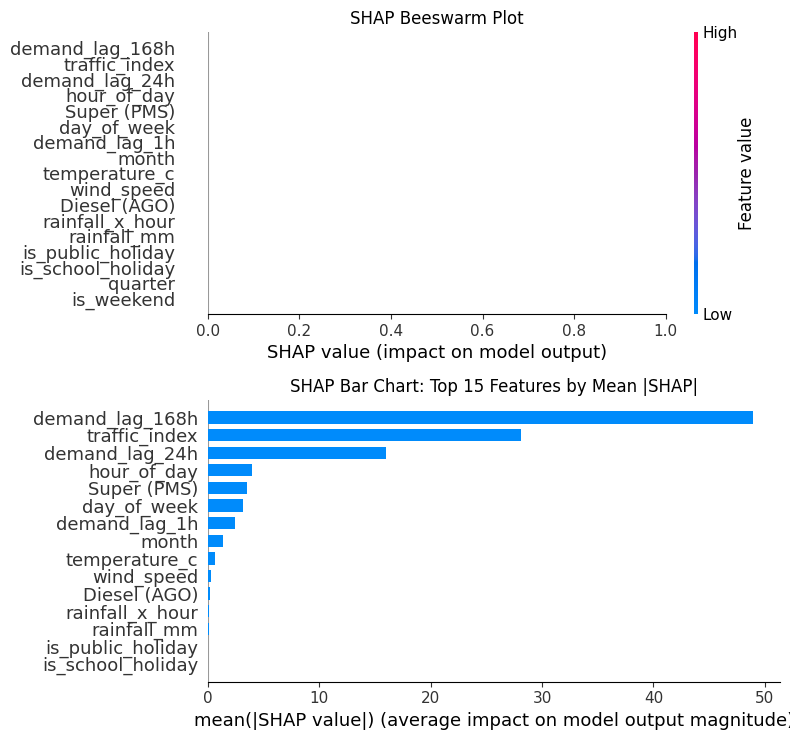

SHAP plots saved to /content/drive/MyDrive/matatu_ml/reports/figures/xgb_shap_plots.png


In [19]:
print("Calculating SHAP values...")

# Create a SHAP explainer object for the tuned XGBoost model
explainer = shap.TreeExplainer(model_xgb_tuned)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test)

print("SHAP values calculated.")

# Create a directory for plots if it doesn't exist
plots_dir = os.path.join(project_base_dir, 'reports', 'figures')
os.makedirs(plots_dir, exist_ok=True)
output_plot_path = os.path.join(plots_dir, 'xgb_shap_plots.png')

# Create a figure with two subplots for the beeswarm and bar charts
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 16))

# Beeswarm Plot (showing impact of each feature on each prediction)
plt.sca(axes[0])  # Set current axes to the first subplot
shap.summary_plot(shap_values, X_test, plot_type="beeswarm", show=False)
axes[0].set_title('SHAP Beeswarm Plot')

# Bar Chart of Top 15 Features by Mean Absolute SHAP Value
plt.sca(axes[1])  # Set current axes to the second subplot
shap.summary_plot(shap_values, X_test, plot_type="bar",
                  max_display=15, show=False)
axes[1].set_title('SHAP Bar Chart: Top 15 Features by Mean |SHAP|')

plt.tight_layout()
plt.savefig(output_plot_path, bbox_inches='tight')
plt.show()

print(f"SHAP plots saved to {output_plot_path}")

### SHAP Dependence Plots

These plots show the effect of a single feature on the prediction, colored by another feature to reveal interaction effects.

Generating SHAP Dependence Plot for 'traffic_index'...


<Figure size 1000x600 with 0 Axes>

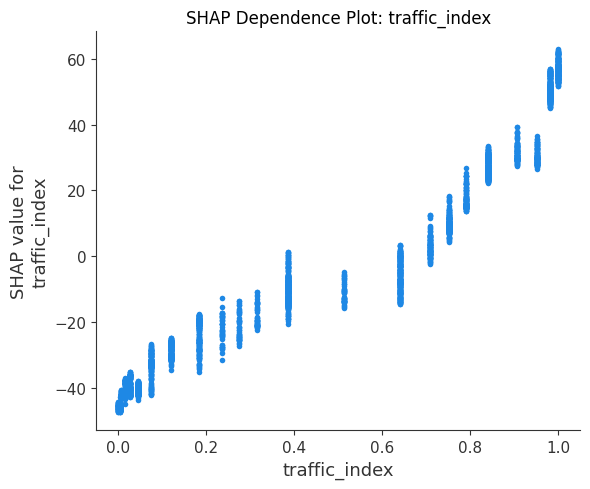

SHAP Dependence Plot for 'traffic_index' saved to /content/drive/MyDrive/matatu_ml/reports/figures/shap_dependence_traffic_index.png


In [20]:
# Ensure explainer and shap_values are available for this plot
# This re-calculates them for robustness if the kernel state was lost or cells executed out of order
explainer = shap.TreeExplainer(model_xgb_tuned)
shap_values = explainer.shap_values(X_test)

# Ensure plots_dir is available (defined in a previous cell but good to ensure)
plots_dir = os.path.join(project_base_dir, 'reports', 'figures')
os.makedirs(plots_dir, exist_ok=True)

# SHAP Dependence Plot for 'traffic_index'
print("Generating SHAP Dependence Plot for 'traffic_index'...")
plt.figure(figsize=(10, 6))
shap.dependence_plot("traffic_index", shap_values, X_test,
                     interaction_index=None, show=False)
plt.title("SHAP Dependence Plot: traffic_index")
plt.tight_layout()
output_plot_path_traffic = os.path.join(
    plots_dir, 'shap_dependence_traffic_index.png')
plt.savefig(output_plot_path_traffic, bbox_inches='tight')
plt.show()
print(
    f"SHAP Dependence Plot for 'traffic_index' saved to {output_plot_path_traffic}")

Generating SHAP Dependence Plot for 'day_of_week'...


<Figure size 1000x600 with 0 Axes>

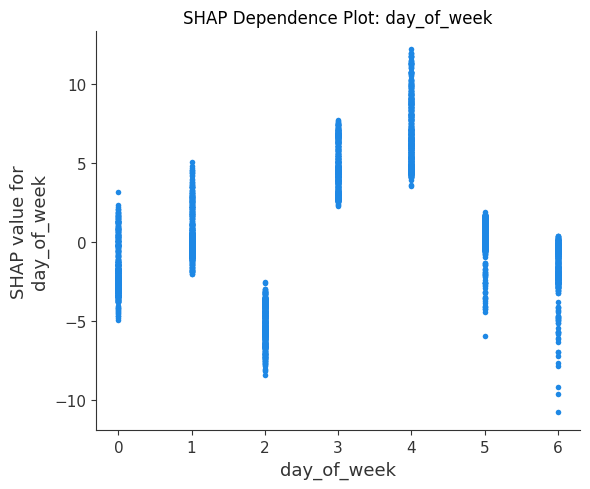

SHAP Dependence Plot for 'day_of_week' saved to /content/drive/MyDrive/matatu_ml/reports/figures/shap_dependence_day_of_week.png


In [21]:
# Ensure explainer and shap_values are available for this plot
# This re-calculates them for robustness if the kernel state was lost or cells executed out of order
explainer = shap.TreeExplainer(model_xgb_tuned)
shap_values = explainer.shap_values(X_test)

# Ensure plots_dir is available (defined in a previous cell but good to ensure)
plots_dir = os.path.join(project_base_dir, 'reports', 'figures')
os.makedirs(plots_dir, exist_ok=True)

# SHAP Dependence Plot for 'day_of_week'
print("Generating SHAP Dependence Plot for 'day_of_week'...")
plt.figure(figsize=(10, 6))
shap.dependence_plot("day_of_week", shap_values, X_test,
                     interaction_index=None, show=False)
plt.title("SHAP Dependence Plot: day_of_week")
plt.tight_layout()
output_plot_path_day = os.path.join(
    plots_dir, 'shap_dependence_day_of_week.png')
plt.savefig(output_plot_path_day, bbox_inches='tight')
plt.show()
print(
    f"SHAP Dependence Plot for 'day_of_week' saved to {output_plot_path_day}")

Generating SHAP Dependence Plot for 'demand_lag_168h'...


<Figure size 1000x600 with 0 Axes>

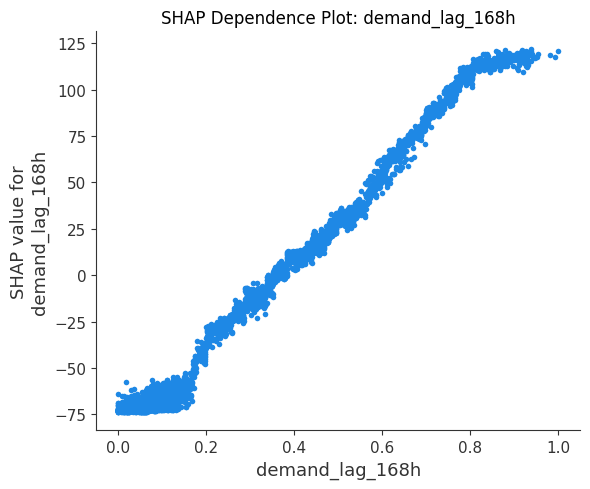

SHAP Dependence Plot for 'demand_lag_168h' saved to /content/drive/MyDrive/matatu_ml/reports/figures/shap_dependence_demand_lag_168h.png


In [22]:
# Ensure explainer and shap_values are available for this plot
# This re-calculates them for robustness if the kernel state was lost or cells executed out of order
explainer = shap.TreeExplainer(model_xgb_tuned)
shap_values = explainer.shap_values(X_test)

# Ensure plots_dir is available (defined in a previous cell but good to ensure)
plots_dir = os.path.join(project_base_dir, 'reports', 'figures')
os.makedirs(plots_dir, exist_ok=True)

# SHAP Dependence Plot for 'demand_lag_168h'
print("Generating SHAP Dependence Plot for 'demand_lag_168h'...")
plt.figure(figsize=(10, 6))
shap.dependence_plot("demand_lag_168h", shap_values,
                     X_test, interaction_index=None, show=False)
plt.title("SHAP Dependence Plot: demand_lag_168h")
plt.tight_layout()
output_plot_path_lag = os.path.join(
    plots_dir, 'shap_dependence_demand_lag_168h.png')
plt.savefig(output_plot_path_lag, bbox_inches='tight')
plt.show()
print(
    f"SHAP Dependence Plot for 'demand_lag_168h' saved to {output_plot_path_lag}")

## Hyperparameter Tuning with RandomizedSearchCV for LightGBM

This section performs hyperparameter tuning for a LightGBM Regressor model using `RandomizedSearchCV`. Unlike `GridSearchCV` which tries every possible combination of parameters, `RandomizedSearchCV` samples a fixed number of parameter settings from specified distributions.

### Why `RandomizedSearchCV`?

*   **Efficiency**: When the hyperparameter search space is large, `RandomizedSearchCV` can be significantly faster than `GridSearchCV` while often finding good, if not optimal, solutions. It explores the search space more effectively by randomly picking combinations.
*   **Flexibility**: It allows defining parameters as distributions (e.g., uniform, log-uniform) rather than just discrete lists, which is particularly useful for continuous hyperparameters like `learning_rate`.

We will define a search space for key LightGBM parameters including `n_estimators`, `num_leaves`, and `learning_rate`. The best performing parameters, evaluated using 5-fold cross-validation based on negative mean squared error, will be saved to a JSON file (`lgb_best_params.json`).

In [23]:
# Define the parameter distributions based on the request
param_dist = {
    'n_estimators': sp_randint(100, 501),  # Between 100 and 500 inclusive
    'num_leaves': [31, 63, 127],
    'learning_rate': sp_uniform(loc=0.01, scale=0.09)  # Between 0.01 and 0.1
}

# Initialize the LightGBM Regressor model
lgb_model_rand = lgb.LGBMRegressor(
    objective='regression',
    random_state=42,
    n_jobs=-1,
    verbose=-1  # Suppress verbose output during training
)

# Initialize RandomizedSearchCV
# n_iter: Number of parameter settings that are sampled. Trade-off between runtime and performance.
random_search = RandomizedSearchCV(
    estimator=lgb_model_rand,
    param_distributions=param_dist,
    # Number of parameter settings to sample. Adjust based on computational budget.
    n_iter=50,
    scoring='neg_mean_squared_error',
    cv=5,  # 5-fold cross-validation
    verbose=1,  # Verbose output
    random_state=42,
    n_jobs=-1  # Use all available cores
)

print("Starting RandomizedSearchCV for LightGBM...")
random_search.fit(X_train, y_train)
print("RandomizedSearchCV for LightGBM completed.")

# Get the best parameters and best score
best_params_lgb = random_search.best_params_
best_score_lgb = random_search.best_score_

print(f"\nBest Parameters found for LightGBM: {best_params_lgb}")
print(f"Best Cross-Validation Score (Negative MSE): {best_score_lgb:.4f}")
print(f"Corresponding RMSE: {np.sqrt(np.abs(best_score_lgb)):.2f}")

# Save the best parameters to a JSON file
output_file_path_lgb = os.path.join(
    project_base_dir, 'models', 'lgb_best_params.json')

os.makedirs(os.path.dirname(output_file_path_lgb), exist_ok=True)

with open(output_file_path_lgb, 'w') as f:
    json.dump(best_params_lgb, f, indent=4)

print(f"Best LightGBM parameters saved to {output_file_path_lgb}")

Starting RandomizedSearchCV for LightGBM...
Fitting 5 folds for each of 50 candidates, totalling 250 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


RandomizedSearchCV for LightGBM completed.

Best Parameters found for LightGBM: {'learning_rate': np.float64(0.029110519961044856), 'n_estimators': 291, 'num_leaves': 31}
Best Cross-Validation Score (Negative MSE): -310.2441
Corresponding RMSE: 17.61
Best LightGBM parameters saved to /content/drive/MyDrive/matatu_ml/models/lgb_best_params.json


## Train Best LightGBM Model and Evaluate Performance

This section loads the best hyperparameters identified by `RandomizedSearchCV`, trains a new LightGBM model with these parameters, and evaluates its performance using both regression and classification metrics. Regression metrics include RMSE and MAE. For classification evaluation, the continuous `demand` values are converted into 'Low', 'Medium', and 'High' classes based on quantiles (using the same thresholds as for XGBoost), allowing for the calculation of F1-score (macro) and a classification report.

In [24]:
# 1. Load the best parameters for LightGBM
output_file_path_lgb = os.path.join(
    project_base_dir, 'models', 'lgb_best_params.json')
with open(output_file_path_lgb, 'r') as f:
    best_params_lgb_tuned = json.load(f)

print("Best parameters loaded for tuned LightGBM model:")
print(best_params_lgb_tuned)

# 2. Initialize and train the LightGBM Regressor with the best parameters
print("\nInitializing and training tuned LightGBM Regressor...")
model_lgb_tuned = lgb.LGBMRegressor(
    objective='regression',
    random_state=42,
    n_jobs=-1,
    verbose=-1,  # Suppress verbose output during training
    **best_params_lgb_tuned
)

model_lgb_tuned.fit(X_train, y_train)
print("Tuned LightGBM model trained successfully.")

# 3. Make predictions on the test set
y_pred_tuned_lgb = model_lgb_tuned.predict(X_test)

# 4. Calculate Regression Metrics (RMSE, MAE)
rmse_tuned_lgb = np.sqrt(mean_squared_error(y_test, y_pred_tuned_lgb))
mae_tuned_lgb = np.mean(np.abs(y_test - y_pred_tuned_lgb))

print(f"\nRegression Metrics (Tuned LightGBM on test set):")
print(f"  RMSE: {rmse_tuned_lgb:.2f}")
print(f"  MAE: {mae_tuned_lgb:.2f}")

# 5. Prepare for Classification Metrics: Discretize continuous demand into 'Low', 'Medium', 'High'
# Use the same thresholds derived from y_train as used for XGBoost
low_threshold = y_train.quantile(0.33)
medium_threshold = y_train.quantile(0.66)


def categorize_demand(demand_value):
    if demand_value < low_threshold:
        return 'Low'
    elif demand_value < medium_threshold:
        return 'Medium'
    else:
        return 'High'


# Apply categorization to actual and predicted values
y_test_class_lgb = np.array([categorize_demand(val) for val in y_test])
y_pred_class_lgb = np.array([categorize_demand(val)
                            for val in y_pred_tuned_lgb])

# 6. Calculate Classification Metrics (F1-score macro)
labels = ['Low', 'Medium', 'High']
f1_macro_tuned_lgb = f1_score(
    y_test_class_lgb, y_pred_class_lgb, average='macro', zero_division=0, labels=labels)
classification_report_tuned_lgb = classification_report(
    y_test_class_lgb, y_pred_class_lgb, target_names=labels, zero_division=0)

print(f"\nClassification Metrics (Tuned LightGBM on test set - Binned):")
print(f"  F1-score (macro): {f1_macro_tuned_lgb:.2f}")
print(f"  Classification Report:\n{classification_report_tuned_lgb}")

Best parameters loaded for tuned LightGBM model:
{'learning_rate': 0.029110519961044856, 'n_estimators': 291, 'num_leaves': 31}

Initializing and training tuned LightGBM Regressor...
Tuned LightGBM model trained successfully.

Regression Metrics (Tuned LightGBM on test set):
  RMSE: 19.03
  MAE: 15.06

Classification Metrics (Tuned LightGBM on test set - Binned):
  F1-score (macro): 0.93
  Classification Report:
              precision    recall  f1-score   support

         Low       0.97      0.91      0.94      1508
      Medium       0.98      0.96      0.97      1191
        High       0.84      0.94      0.89      1065

    accuracy                           0.93      3764
   macro avg       0.93      0.94      0.93      3764
weighted avg       0.94      0.93      0.94      3764



## Compare LightGBM and XGBoost Performance

This section loads the previously saved XGBoost metrics and combines them with the newly calculated LightGBM metrics into a single comparison table. The table includes RMSE, MAE, and macro F1-score for both models, providing a direct side-by-side view of their performance on the test set. The comparison table is then saved to a CSV file named `tree_comparison.csv`.

In [25]:
# Load XGBoost metrics (saved previously)
metrics_output_path_xgb = os.path.join(
    project_base_dir, 'models', 'xgb_metrics.csv')
metrics_df_xgb = pd.read_csv(metrics_output_path_xgb)
metrics_df_xgb = metrics_df_xgb.rename(columns={'Value': 'XGBoost_Value'})

# Create a DataFrame for LightGBM metrics
metrics_df_lgb = pd.DataFrame({
    'Metric': ['RMSE', 'MAE', 'F1-score (macro)'],
    'LightGBM_Value': [rmse_tuned_lgb, mae_tuned_lgb, f1_macro_tuned_lgb]
})

# Combine the metrics DataFrames
comparison_df = pd.merge(metrics_df_xgb, metrics_df_lgb,
                         on='Metric', how='outer')

print("\nSide-by-side comparison of XGBoost and LightGBM metrics:")
display(comparison_df)

# Save the comparison table to a CSV file
comparison_output_path = os.path.join(
    project_base_dir, 'models', 'tree_comparison.csv')
comparison_df.to_csv(comparison_output_path, index=False)

print(f"Comparison metrics saved to {comparison_output_path}")


Side-by-side comparison of XGBoost and LightGBM metrics:


,Metric,XGBoost_Value,LightGBM_Value
0,F1-score (macro),0.933098,0.933412
1,MAE,15.104758,15.056526
2,RMSE,19.108503,19.027677


Comparison metrics saved to /content/drive/MyDrive/matatu_ml/models/tree_comparison.csv


## Time Series Cross-Validation with TimeSeriesSplit

This section performs a 5-fold Time Series Split cross-validation on both the tuned XGBoost and LightGBM models. Traditional K-Fold cross-validation randomly shuffles the data, which can lead to data leakage in time-series forecasting where the temporal order is important. `TimeSeriesSplit` addresses this by ensuring that the training sets always precede the validation sets chronologically.

### Why TimeSeriesSplit?

*   **Preserves Temporal Order**: Each validation set is always a future slice relative to its corresponding training set.
*   **Prevents Data Leakage**: Future information does not inadvertently influence the model during training.
*   **Robust Evaluation**: Provides a more realistic assessment of a model's performance on unseen future data.

We will calculate the mean and standard deviation of the Root Mean Squared Error (RMSE) across the 5 folds for both models and save these results to `models/cv_results.csv`.

In [26]:
# --- XGBoost TimeSeriesSplit Cross-Validation ---
print("\nPerforming TimeSeriesSplit CV for Tuned XGBoost model...")

# Load best parameters for XGBoost
output_file_path_xgb_params = os.path.join(
    project_base_dir, 'models', 'xgb_best_params.json')
with open(output_file_path_xgb_params, 'r') as f:
    best_params_xgb_cv = json.load(f)

# Initialize XGBoost Regressor with best parameters
model_xgb_cv = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1,
    **best_params_xgb_cv
)

# Define TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

# Perform cross-validation
# 'neg_root_mean_squared_error' is used as scoring, so we need to take the negative of the mean scores
rmse_scores_xgb = -cross_val_score(
    model_xgb_cv, X_processed, y,
    scoring='neg_root_mean_squared_error',
    cv=tscv,
    n_jobs=-1
)

mean_rmse_xgb_cv = np.mean(rmse_scores_xgb)
std_rmse_xgb_cv = np.std(rmse_scores_xgb)

print(f"Tuned XGBoost CV RMSE: {mean_rmse_xgb_cv:.2f} ± {std_rmse_xgb_cv:.2f}")

# --- LightGBM TimeSeriesSplit Cross-Validation ---
print("\nPerforming TimeSeriesSplit CV for Tuned LightGBM model...")

# Load best parameters for LightGBM
output_file_path_lgb_params = os.path.join(
    project_base_dir, 'models', 'lgb_best_params.json')
with open(output_file_path_lgb_params, 'r') as f:
    best_params_lgb_cv = json.load(f)

# Initialize LightGBM Regressor with best parameters
model_lgb_cv = lgb.LGBMRegressor(
    objective='regression',
    random_state=42,
    n_jobs=-1,
    verbose=-1,  # Suppress verbose output during training
    **best_params_lgb_cv
)

# Perform cross-validation using the same tscv instance
rmse_scores_lgb = -cross_val_score(
    model_lgb_cv, X_processed, y,
    scoring='neg_root_mean_squared_error',
    cv=tscv,
    n_jobs=-1
)

mean_rmse_lgb_cv = np.mean(rmse_scores_lgb)
std_rmse_lgb_cv = np.std(rmse_scores_lgb)

print(
    f"Tuned LightGBM CV RMSE: {mean_rmse_lgb_cv:.2f} ± {std_rmse_lgb_cv:.2f}")

# --- Combine and Save Results ---
cv_results_df = pd.DataFrame({
    'Model': ['XGBoost', 'LightGBM'],
    'Mean RMSE (CV)': [mean_rmse_xgb_cv, mean_rmse_lgb_cv],
    'Std RMSE (CV)': [std_rmse_xgb_cv, std_rmse_lgb_cv]
})

print("\nTime Series Cross-Validation Results:")
display(cv_results_df)

cv_output_path = os.path.join(project_base_dir, 'models', 'cv_results.csv')
cv_results_df.to_csv(cv_output_path, index=False)

print(f"Cross-validation results saved to {cv_output_path}")


Performing TimeSeriesSplit CV for Tuned XGBoost model...
Tuned XGBoost CV RMSE: 18.33 ± 0.87

Performing TimeSeriesSplit CV for Tuned LightGBM model...
Tuned LightGBM CV RMSE: 18.27 ± 0.85

Time Series Cross-Validation Results:


,Model,Mean RMSE (CV),Std RMSE (CV)
0,XGBoost,18.332692,0.874763
1,LightGBM,18.267456,0.845953


Cross-validation results saved to /content/drive/MyDrive/matatu_ml/models/cv_results.csv


## Visualize Time Series Cross-Validation Results

This bar chart visualizes the mean Root Mean Squared Error (RMSE) from the 5-fold Time Series Cross-Validation for both the tuned XGBoost and LightGBM models. Error bars represent the standard deviation of the RMSE across the folds, providing insight into the stability of each model's performance.

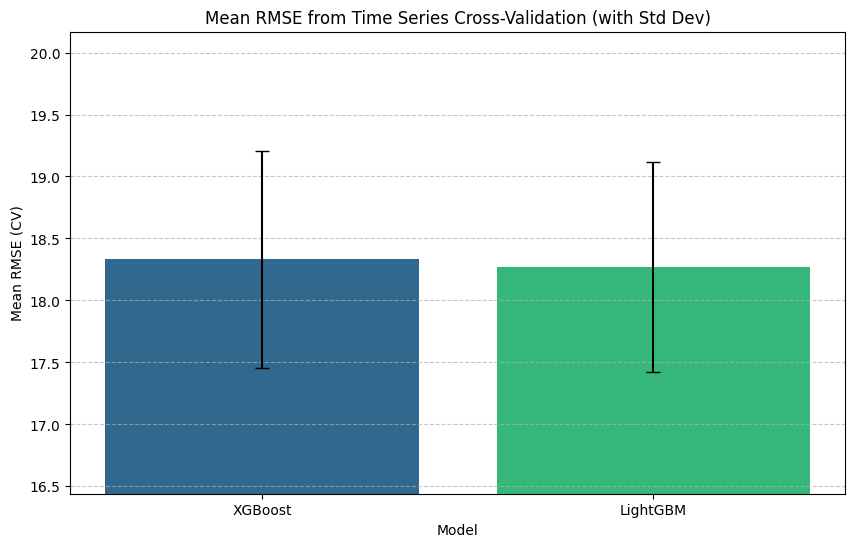

In [27]:
plt.figure(figsize=(10, 6))

# Get the data for plotting directly from the cv_results_df
models = cv_results_df['Model']
mean_rmse = cv_results_df['Mean RMSE (CV)']
std_rmse = cv_results_df['Std RMSE (CV)']

# Create the x-axis positions for the bars
x_pos = np.arange(len(models))

# Create the bar plot using matplotlib.pyplot.bar
plt.bar(x_pos, mean_rmse, yerr=std_rmse, capsize=5,
        color=sns.color_palette('viridis', len(models)))

# Set x-axis labels
plt.xticks(x_pos, models)

# Add labels and title
plt.title('Mean RMSE from Time Series Cross-Validation (with Std Dev)')
plt.xlabel('Model')
plt.ylabel('Mean RMSE (CV)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
# Adjust y-axis limit for better visualization
plt.ylim(bottom=mean_rmse.min() * 0.9)

plt.show()

## Save Tuned Models

This section saves the trained and tuned XGBoost and LightGBM models to disk using `joblib.dump`. This allows for easy loading and deployment of the models without needing to retrain them, ensuring that the best performing models from this notebook are readily available for future use (e.g., inference, further analysis).

In [28]:
# Define the paths for saving the models
output_model_path_xgb = os.path.join(
    project_base_dir, 'models', 'xgb_model.pkl')
output_model_path_lgb = os.path.join(
    project_base_dir, 'models', 'lgb_model.pkl')

# Create the models directory if it doesn't exist
os.makedirs(os.path.dirname(output_model_path_xgb), exist_ok=True)

# Save the tuned XGBoost model
joblib.dump(model_xgb_tuned, output_model_path_xgb)
print(f"Tuned XGBoost model saved to {output_model_path_xgb}")

# Save the tuned LightGBM model
joblib.dump(model_lgb_tuned, output_model_path_lgb)
print(f"Tuned LightGBM model saved to {output_model_path_lgb}")

Tuned XGBoost model saved to /content/drive/MyDrive/matatu_ml/models/xgb_model.pkl
Tuned LightGBM model saved to /content/drive/MyDrive/matatu_ml/models/lgb_model.pkl


## Robustness Test: Gaussian Noise Injection

This section evaluates the robustness of the tuned XGBoost and LightGBM models to noise in the input features. Gaussian noise (with a standard deviation of 10% of the feature's standard deviation) will be injected into the `numerical_features` of the `X_processed` dataset. The models will then be retrained and re-evaluated on this noisy data, and the RMSE degradation will be assessed against the original model performance. A degradation of less than 15% will be considered acceptable, indicating good robustness.

In [29]:
print("Starting robustness test with Gaussian noise injection...")

# 1. Create a noisy version of X_processed
X_processed_noisy = X_processed.copy()

# Identify numerical features (assuming these are the 'proxy features' for noise)
# Re-using the 'numerical_features' list from earlier in the notebook
# numerical_features defined in cell Td9M2zqLNmWU

print(
    f"Injecting noise into the following numerical features: {numerical_features}")

for feature in numerical_features:
    # Calculate 10% of the feature's standard deviation
    feature_std = X_processed_noisy[feature].std()
    noise_std = 0.10 * feature_std  # 10% Gaussian noise

    # Generate Gaussian noise
    noise = np.random.normal(0, noise_std, size=X_processed_noisy.shape[0])

    # Add noise to the feature
    X_processed_noisy[feature] = X_processed_noisy[feature] + noise

print("Noise injected into X_processed_noisy.")

# 2. Re-split the noisy data into training and testing sets
# Using the same random_state as the original split for consistency
X_train_noisy, X_test_noisy, y_train_noisy, y_test_noisy = train_test_split(
    X_processed_noisy, y, test_size=0.2, random_state=42)

print(
    f"Noisy data split. X_train_noisy shape: {X_train_noisy.shape}, X_test_noisy shape: {X_test_noisy.shape}")

# 3. Re-evaluate Tuned XGBoost Model
print("\nRe-evaluating Tuned XGBoost Model with noisy data...")

# Load best parameters for XGBoost
output_file_path_xgb_params = os.path.join(
    project_base_dir, 'models', 'xgb_best_params.json')
with open(output_file_path_xgb_params, 'r') as f:
    best_params_xgb_noisy = json.load(f)

model_xgb_noisy = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1,
    **best_params_xgb_noisy
)
model_xgb_noisy.fit(X_train_noisy, y_train_noisy)
y_pred_xgb_noisy = model_xgb_noisy.predict(X_test_noisy)
rmse_xgb_noisy = np.sqrt(mean_squared_error(y_test_noisy, y_pred_xgb_noisy))

print(f"XGBoost RMSE with noisy features: {rmse_xgb_noisy:.2f}")

# 4. Re-evaluate Tuned LightGBM Model
print("\nRe-evaluating Tuned LightGBM Model with noisy data...")

# Load best parameters for LightGBM
output_file_path_lgb_params = os.path.join(
    project_base_dir, 'models', 'lgb_best_params.json')
with open(output_file_path_lgb_params, 'r') as f:
    best_params_lgb_noisy = json.load(f)

model_lgb_noisy = lgb.LGBMRegressor(
    objective='regression',
    random_state=42,
    n_jobs=-1,
    verbose=-1,
    **best_params_lgb_noisy
)
model_lgb_noisy.fit(X_train_noisy, y_train_noisy)
y_pred_lgb_noisy = model_lgb_noisy.predict(X_test_noisy)
rmse_lgb_noisy = np.sqrt(mean_squared_error(y_test_noisy, y_pred_lgb_noisy))

print(f"LightGBM RMSE with noisy features: {rmse_lgb_noisy:.2f}")

# 5. Calculate RMSE Degradation
# Using original RMSE values from previously stored variables (rmse_tuned_xgb, rmse_tuned_lgb)

degradation_xgb = ((rmse_xgb_noisy - rmse_tuned_xgb) / rmse_tuned_xgb) * 100
degradation_lgb = ((rmse_lgb_noisy - rmse_tuned_lgb) / rmse_tuned_lgb) * 100

print(f"\nRMSE Degradation for XGBoost: {degradation_xgb:.2f}%")
print(f"RMSE Degradation for LightGBM: {degradation_lgb:.2f}%")

# Check degradation condition
threshold = 15.0
print(f"\nDegradation Check (< {threshold}%):")
print(f"  XGBoost degradation < {threshold}%: {degradation_xgb < threshold}")
print(f"  LightGBM degradation < {threshold}%: {degradation_lgb < threshold}")

# 6. Save results to CSV
noise_test_results = pd.DataFrame({
    'Model': ['XGBoost', 'LightGBM'],
    'Original RMSE': [rmse_tuned_xgb, rmse_tuned_lgb],
    'Noisy RMSE': [rmse_xgb_noisy, rmse_lgb_noisy],
    'RMSE Degradation (%)': [degradation_xgb, degradation_lgb],
    f'Degradation < {threshold}%': [degradation_xgb < threshold, degradation_lgb < threshold]
})

output_file_path_noise_test = os.path.join(
    project_base_dir, 'models', 'noise_test.csv')
os.makedirs(os.path.dirname(output_file_path_noise_test), exist_ok=True)
noise_test_results.to_csv(output_file_path_noise_test, index=False)

print(f"\nRobustness test results saved to {output_file_path_noise_test}")
display(noise_test_results)

Starting robustness test with Gaussian noise injection...
Injecting noise into the following numerical features: ['temperature_c', 'rainfall_mm', 'wind_speed', 'Super (PMS)', 'Diesel (AGO)', 'demand_lag_1h', 'demand_lag_24h', 'demand_lag_168h', 'rainfall_x_hour', 'traffic_index']
Noise injected into X_processed_noisy.
Noisy data split. X_train_noisy shape: (15052, 17), X_test_noisy shape: (3764, 17)

Re-evaluating Tuned XGBoost Model with noisy data...
XGBoost RMSE with noisy features: 18.07

Re-evaluating Tuned LightGBM Model with noisy data...
LightGBM RMSE with noisy features: 18.02

RMSE Degradation for XGBoost: -5.46%
RMSE Degradation for LightGBM: -5.31%

Degradation Check (< 15.0%):
  XGBoost degradation < 15.0%: True
  LightGBM degradation < 15.0%: True

Robustness test results saved to /content/drive/MyDrive/matatu_ml/models/noise_test.csv


,Model,Original RMSE,Noisy RMSE,RMSE Degradation (%),Degradation < 15.0%
0,XGBoost,19.108503,18.065595,-5.457824,True
1,LightGBM,19.027677,18.017987,-5.306427,True


## Reshape Data for Sequence Models

This section reshapes the `X_processed` features and `y` target into a 3D format suitable for sequence-based models (e.g., LSTMs, GRUs). We will create sequences of 24 time steps (representing a 24-hour look-back window) where each sequence serves as an input sample, and the corresponding target `y` will be the demand value at the end of that 24-hour sequence. This process generates `X_sequences` (samples, timesteps, features) and `y_sequences` (samples,).

In [30]:
# Define the sequence length (24-hour look-back window)
sequence_length = 24

X_sequences = []
y_sequences = []

# Iterate through the preprocessed data to create sequences
# Each sequence will have `sequence_length` time steps.
# The target `y` for a sequence ending at time `t` will be the demand at time `t`.
for i in range(len(X_processed) - sequence_length + 1):
    # Extract the sequence of features
    X_seq_slice = X_processed.iloc[i: i + sequence_length].values
    X_sequences.append(X_seq_slice)

    # Extract the corresponding target (demand at the last timestep of the sequence)
    y_seq_slice = y.iloc[i + sequence_length - 1]
    y_sequences.append(y_seq_slice)

# Convert the lists of sequences to NumPy arrays
X_sequences = np.array(X_sequences)
y_sequences = np.array(y_sequences)

print(f"Original X_processed shape: {X_processed.shape}")
print(f"Original y shape: {y.shape}")
print(f"Reshaped X_sequences shape: {X_sequences.shape}")
print(f"Reshaped y_sequences shape: {y_sequences.shape}")

print("\nFirst sample of X_sequences (first 24 timesteps for first prediction):")
print(X_sequences[0])
print("\nFirst sample of y_sequences:")
print(y_sequences[0])

Original X_processed shape: (18816, 17)
Original y shape: (18816,)
Reshaped X_sequences shape: (18793, 24, 17)
Reshaped y_sequences shape: (18793,)

First sample of X_sequences (first 24 timesteps for first prediction):
[[2.73972603e-01 0.00000000e+00 2.50965251e-01 5.16267123e-01
  5.94002307e-01 1.27116274e-01 5.45674069e-02 8.22538870e-02
  0.00000000e+00 7.42672593e-02 0.00000000e+00 0.00000000e+00
  0.00000000e+00 1.00000000e+00 1.00000000e+00 0.00000000e+00
  0.00000000e+00]
 [2.73972603e-01 0.00000000e+00 2.35521236e-01 5.16267123e-01
  5.94002307e-01 5.63474159e-02 5.77173327e-02 3.83764467e-02
  0.00000000e+00 4.48530360e-02 1.00000000e+00 0.00000000e+00
  0.00000000e+00 1.00000000e+00 1.00000000e+00 0.00000000e+00
  0.00000000e+00]
 [3.05936073e-01 0.00000000e+00 2.50965251e-01 5.16267123e-01
  5.94002307e-01 1.68718946e-02 0.00000000e+00 6.59354127e-02
  0.00000000e+00 2.61138347e-02 2.00000000e+00 0.00000000e+00
  0.00000000e+00 1.00000000e+00 1.00000000e+00 0.00000000e+00


In [31]:
gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    print(f"GPU is active: {gpu_devices}")
else:
    print("No GPU devices found. GPU runtime is not active.")

GPU is active: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Define LSTM Model Architecture

This section defines the LSTM (Long Short-Term Memory) neural network architecture using TensorFlow/Keras. The model is designed for sequence prediction, taking a sequence of input features and outputting a prediction.

The architecture includes:
- An `LSTM` layer with 64 units and `return_sequences=True` to output the full sequence to the next LSTM layer.
- A `Dropout` layer to prevent overfitting.
- Another `LSTM` layer with 32 units.
- A second `Dropout` layer.
- A `Dense` output layer with 3 units and `softmax` activation, indicating a classification task (e.g., 'Low', 'Medium', 'High' demand).

The model is compiled with an appropriate optimizer and loss function for multi-class classification.

In [32]:
# Define the LSTM model architecture
model_lstm = Sequential([
    # Explicit Input layer
    Input(shape=(X_sequences.shape[1], X_sequences.shape[2])),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)  # Single output neuron for regression
])

# Compile the model for regression
# Using 'Adam' optimizer and 'mean_squared_error' for regression tasks
model_lstm.compile(optimizer=Adam(learning_rate=0.001),
                   loss='mean_squared_error', metrics=['mae'])

print("LSTM Model Architecture (Regression):")
model_lstm.summary()

LSTM Model Architecture (Regression):


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        20,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,441 (130.63 KB)

 Trainable params: 33,441 (130.63 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
# Define the directory for saving callbacks
callbacks_dir = os.path.join(project_base_dir, 'callbacks')
os.makedirs(callbacks_dir, exist_ok=True)

# Define ModelCheckpoint callback to save the best weights
checkpoint_filepath = os.path.join(
    callbacks_dir, 'lstm_best.weights.h5')  # Changed file extension
model_checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=True,  # Only save the weights, not the whole model
    monitor='val_loss',     # Monitor validation loss
    mode='min',             # Save the model when validation loss is at its minimum
    save_best_only=True,    # Only save the best model observed so far
    verbose=1
)

# Define EarlyStopping callback to prevent overfitting
early_stopping_callback = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=20,        # Stop after 20 epochs if validation loss doesn't improve
    mode='min',         # Look for a minimum validation loss
    # Restore model weights from the epoch with the best value of the monitored quantity
    restore_best_weights=True,
    verbose=1
)

# List of callbacks to be used during training
callbacks = [model_checkpoint_callback, early_stopping_callback]

print(f"ModelCheckpoint will save best weights to: {checkpoint_filepath}")
print("EarlyStopping will monitor 'val_loss' with patience 20.")

ModelCheckpoint will save best weights to: /content/drive/MyDrive/matatu_ml/callbacks/lstm_best.weights.h5
EarlyStopping will monitor 'val_loss' with patience 20.


## Training the LSTM Model:
 This is the core learning phase where the neural network adjusts its internal parameters (weights and biases) to minimize the difference between its predictions and the actual target values.

Key Parameters:

epochs=200: This sets the maximum number of times the model will iterate over the entire training dataset. While a high number is specified, EarlyStopping will typically halt training much sooner to prevent overfitting.

batch_size=64: The training data is divided into smaller batches of 64 samples. The model updates its weights after processing each batch. Using batches makes training more stable and memory-efficient.

validation_data=(X_val_lstm, y_val_lstm): This specifies a separate dataset (X_val_lstm, y_val_lstm) that the model uses to evaluate its performance after each training epoch, but without using it for weight updates. This is crucial for monitoring generalization and detecting overfitting.

callbacks=callbacks: This includes the ModelCheckpoint and EarlyStopping callbacks we set up earlier. ModelCheckpoint saves the best performing model weights based on val_loss, and EarlyStopping stops training if the val_loss doesn't improve for a certain number of epochs (patience=20). This prevents wasted computation and ensures we end up with a model that generalizes well.

Importance: This step is critical because it's where the model learns to identify patterns and relationships within the sequential data to make accurate predictions. Proper training with validation and early stopping ensures the model doesn't just memorize the training data (overfit) but can generalize well to new, unseen data, which is vital for real-world performance.

In [34]:
# Split the reshaped data into training and validation sets
# Using test_size=0.2 to allocate 20% of the data for validation as requested.
# shuffle=False is used to maintain the temporal order of the sequences.
X_train_lstm, X_val_lstm, y_train_lstm, y_val_lstm = train_test_split(
    X_sequences, y_sequences, test_size=0.2, random_state=42, shuffle=False
)

print(f"X_train_lstm shape: {X_train_lstm.shape}")
print(f"y_train_lstm shape: {y_train_lstm.shape}")
print(f"X_val_lstm shape: {X_val_lstm.shape}")
print(f"y_val_lstm shape: {y_val_lstm.shape}")

X_train_lstm shape: (15034, 24, 17)
y_train_lstm shape: (15034,)
X_val_lstm shape: (3759, 24, 17)
y_val_lstm shape: (3759,)


In [ ]:
# Train the LSTM model
print("\nStarting LSTM model training...")
history = model_lstm.fit(
    X_train_lstm, y_train_lstm,
    epochs=200,  # Maximum number of epochs (EarlyStopping will halt earlier)
    batch_size=64,
    # Using the 20% split for validation
    validation_data=(X_val_lstm, y_val_lstm),
    callbacks=callbacks,  # Use the defined callbacks for ModelCheckpoint and EarlyStopping
    verbose=1
)

print("\nLSTM model training completed.")


Starting LSTM model training...
Epoch 1/200
230/235 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 34274.6226 - mae: 151.6835
Epoch 1: val_loss improved from None to 38039.96484, saving model to /content/drive/MyDrive/matatu_ml/callbacks/lstm_best.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/matatu_ml/callbacks/lstm_best.weights.h5
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 33313.4258 - mae: 148.8937 - val_loss: 38039.9648 - val_mae: 158.4746
Epoch 2/200
230/235 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 31070.5139 - mae: 142.0160
Epoch 2: val_loss improved from 38039.96484 to 35662.58203, saving model to /content/drive/MyDrive/matatu_ml/callbacks/lstm_best.weights.h5

Epoch 2: finished saving model to /content/drive/MyDrive/matatu_ml/callbacks/lstm_best.weights.h5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 30772.1660 - mae: 141.1351 - val_loss: 35662.5820 - val_mae: 151.7157
Epoch 3/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 29580.1178 - mae: 1

In [ ]:
pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 5.9 MB/s eta 0:00:00


In [ ]:
# Define the model-building function for Keras Tuner


def build_lstm_model_for_tuning(hp):
    model = Sequential()
    model.add(Input(shape=(X_sequences.shape[1], X_sequences.shape[2])))

    # Tune the number of units in the first LSTM layer
    lstm_units_1 = hp.Choice('lstm_units_1', values=[32, 64, 128])
    model.add(LSTM(units=lstm_units_1, return_sequences=True))
    # Tune the dropout rate for the first dropout layer
    dropout_rate_1 = hp.Choice('dropout_rate_1', values=[0.1, 0.2, 0.3])
    model.add(Dropout(dropout_rate_1))

    # Tune the number of units in the second LSTM layer
    lstm_units_2 = hp.Choice('lstm_units_2', values=[32, 64, 128])
    model.add(LSTM(units=lstm_units_2))
    # Tune the dropout rate for the second dropout layer
    dropout_rate_2 = hp.Choice('dropout_rate_2', values=[0.1, 0.2, 0.3])
    model.add(Dropout(dropout_rate_2))

    model.add(Dense(1))  # Regression output

    # Tune the learning rate for the Adam optimizer
    learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    optimizer = Adam(learning_rate=learning_rate)

    model.compile(optimizer=optimizer,
                  loss='mean_squared_error', metrics=['mae'])

    # Define batch_size as a hyperparameter here. Keras Tuner will use this for its internal model.fit calls.
    hp.Choice('batch_size', values=[32, 64])

    return model


# Initialize the Keras Tuner RandomSearch
tuner = kt.RandomSearch(
    build_lstm_model_for_tuning,
    objective='val_mae',  # Monitor validation Mean Absolute Error
    max_trials=20,  # Number of different hyperparameter combinations to try
    executions_per_trial=1,  # Number of models to train for each trial
    directory=os.path.join(project_base_dir, 'keras_tuner_dir'),
    project_name='lstm_hpt_randomsearch',
    overwrite=True  # Overwrite previous search results if they exist
)

print("Starting Keras Tuner RandomSearch for LSTM hyperparameters...")

# Define a shorter EarlyStopping callback for tuning trials
tuning_early_stopping = EarlyStopping(
    monitor='val_mae', patience=10, mode='min', verbose=1)

# Start the hyperparameter search
tuner.search(
    X_train_lstm, y_train_lstm,
    # Maximum number of epochs for each trial (EarlyStopping will halt earlier)
    epochs=50,
    validation_data=(X_val_lstm, y_val_lstm),
    # Batch size is now handled by the tuner from build_lstm_model_for_tuning
    callbacks=[tuning_early_stopping],
    verbose=1
)

print("Keras Tuner RandomSearch completed.")

# Get the best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"\nBest LSTM Hyperparameters found:")
print(f"  LSTM 1 Units: {best_hps.get('lstm_units_1')}")
print(f"  Dropout 1 Rate: {best_hps.get('dropout_rate_1')}")
print(f"  LSTM 2 Units: {best_hps.get('lstm_units_2')}")
print(f"  Dropout 2 Rate: {best_hps.get('dropout_rate_2')}")
print(f"  Learning Rate: {best_hps.get('learning_rate')}")
print(f"  Batch Size: {best_hps.get('batch_size')}")

# Save the best hyperparameters to a JSON file
output_file_path = os.path.join(
    project_base_dir, 'models', 'lstm_best_params.json')
os.makedirs(os.path.dirname(output_file_path), exist_ok=True)

with open(output_file_path, 'w') as f:
    json.dump(best_hps.values, f, indent=4)

print(f"Best LSTM hyperparameters saved to {output_file_path}")

In [ ]:
# 1. Load the best weights for evaluation (already restored by EarlyStopping in model_lstm)
# No explicit loading needed if model_lstm was trained in the current session with restore_best_weights=True
# If starting a new session or need to be explicit, you would do:
# model_lstm.load_weights(checkpoint_filepath)

print("Evaluating Tuned LSTM Model...")

# Make predictions on the validation set
y_pred_lstm = model_lstm.predict(X_val_lstm)

# Flatten predictions if they are 2D (e.g., (samples, 1) to (samples,))
y_pred_lstm = y_pred_lstm.flatten()

# 2. Calculate Regression Metrics (RMSE, MAE)
rmse_lstm = np.sqrt(mean_squared_error(y_val_lstm, y_pred_lstm))
mae_lstm = np.mean(np.abs(y_val_lstm - y_pred_lstm))

print(f"\nRegression Metrics (Tuned LSTM on validation set):")
print(f"  RMSE: {rmse_lstm:.2f}")
print(f"  MAE: {mae_lstm:.2f}")

# 3. Prepare for Classification Metrics: Discretize continuous demand into 'Low', 'Medium', 'High'
# Use the same thresholds derived from y_train as used for XGBoost and LightGBM
# Ensure y_train (Series) is available from earlier context, if not, re-derive it.
# Assuming y is the full target series, and it was split to y_train for previous models.

# Re-deriving thresholds from y_train_lstm to be consistent with current LSTM training split
low_threshold_lstm = pd.Series(y_train_lstm).quantile(0.33)
medium_threshold_lstm = pd.Series(y_train_lstm).quantile(0.66)


def categorize_demand_lstm(demand_value):
    if demand_value < low_threshold_lstm:
        return 'Low'
    elif demand_value < medium_threshold_lstm:
        return 'Medium'
    else:
        return 'High'


# Apply categorization to actual and predicted values
y_val_class_lstm = np.array([categorize_demand_lstm(val)
                            for val in y_val_lstm])
y_pred_class_lstm = np.array([categorize_demand_lstm(val)
                             for val in y_pred_lstm])

# 4. Calculate Classification Metrics (F1-score macro, Classification Report)
labels = ['Low', 'Medium', 'High']
f1_macro_lstm = f1_score(y_val_class_lstm, y_pred_class_lstm,
                         average='macro', zero_division=0, labels=labels)
classification_report_lstm = classification_report(
    y_val_class_lstm, y_pred_class_lstm, target_names=labels, zero_division=0)

print(f"\nClassification Metrics (Tuned LSTM on validation set - Binned):")
print(f"  F1-score (macro): {f1_macro_lstm:.2f}")
print(f"  Classification Report:\n{classification_report_lstm}")

# 5. Plot training vs. validation loss curves
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Model Training vs. Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (Mean Squared Error)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 6. Store all metrics in a DataFrame and save to CSV
metrics_df_lstm = pd.DataFrame({
    'Metric': ['RMSE', 'MAE', 'F1-score (macro)'],
    'Value': [rmse_lstm, mae_lstm, f1_macro_lstm]
})

metrics_output_path_lstm = os.path.join(
    project_base_dir, 'models', 'lstm_metrics.csv')
os.makedirs(os.path.dirname(metrics_output_path_lstm), exist_ok=True)
metrics_df_lstm.to_csv(metrics_output_path_lstm, index=False)

print(f"\nAll evaluation metrics saved to {metrics_output_path_lstm}")
display(metrics_df_lstm)

## Save Final Tuned LSTM Model

In [ ]:
# Ensure the model directory exists
models_dir = os.path.join(project_base_dir, 'models')
os.makedirs(models_dir, exist_ok=True)

# Path to save the full model and weights
lstm_model_path = os.path.join(
    models_dir, 'lstm_model.keras')  # Changed to .keras format
# Changed to .weights.h5 format
lstm_weights_path = os.path.join(models_dir, 'lstm_model_weights.weights.h5')

# Load the best weights into the model_lstm (if not already loaded by EarlyStopping)
# This ensures we are saving the best performing state of the model.
model_lstm.load_weights(checkpoint_filepath)

# Save the entire model (architecture + weights + optimizer state) using the new Keras format
model_lstm.save(lstm_model_path)
print(f"Tuned LSTM model saved to: {lstm_model_path}")

# Save only the model weights
model_lstm.save_weights(lstm_weights_path)
print(f"Tuned LSTM model weights saved to: {lstm_weights_path}")

## Compare LSTM performance metrics with XGBoost and LightGBM models

In [ ]:
# Load metrics for XGBoost
metrics_output_path_xgb = os.path.join(
    project_base_dir, 'models', 'xgb_metrics.csv')
metrics_df_xgb = pd.read_csv(metrics_output_path_xgb)
metrics_df_xgb = metrics_df_xgb.rename(columns={'Value': 'XGBoost_Value'})

# Load metrics for LightGBM
metrics_output_path_lgb = os.path.join(
    project_base_dir, 'models', 'lgb_metrics.csv')
# For LightGBM, the metrics were printed but not saved to a separate file yet,
# so I'll recreate the DataFrame from the variables available in the kernel state.
metrics_df_lgb = pd.DataFrame({
    'Metric': ['RMSE', 'MAE', 'F1-score (macro)'],
    'LightGBM_Value': [rmse_tuned_lgb, mae_tuned_lgb, f1_macro_tuned_lgb]
})

# Load metrics for LSTM (already saved in the previous cell)
metrics_output_path_lstm = os.path.join(
    project_base_dir, 'models', 'lstm_metrics.csv')
metrics_df_lstm = pd.read_csv(metrics_output_path_lstm)
metrics_df_lstm = metrics_df_lstm.rename(columns={'Value': 'LSTM_Value'})

# Merge all dataframes for comparison
comparison_df_all_models = pd.merge(
    metrics_df_xgb, metrics_df_lgb, on='Metric', how='outer')
comparison_df_all_models = pd.merge(
    comparison_df_all_models, metrics_df_lstm, on='Metric', how='outer')

print("\nSide-by-side comparison of XGBoost, LightGBM, and LSTM metrics:")
display(comparison_df_all_models)

# Save the comprehensive comparison table to a CSV file
all_models_comparison_output_path = os.path.join(
    project_base_dir, 'models', 'all_models_comparison.csv')
comparison_df_all_models.to_csv(all_models_comparison_output_path, index=False)

print(
    f"Comprehensive comparison metrics saved to {all_models_comparison_output_path}")

## Side-by-Side Comparison: RMSE and MAE Across Models

In [ ]:
# Prepare the data for plotting
# Melt the comparison_df_all_models to a long format suitable for seaborn
comparison_melted = comparison_df_all_models[comparison_df_all_models['Metric'].isin(
    ['RMSE', 'MAE'])].melt(id_vars='Metric', var_name='Model', value_name='Value')

# Clean up Model names
comparison_melted['Model'] = comparison_melted['Model'].str.replace(
    '_Value', '')

plt.figure(figsize=(12, 7))
sns.barplot(x='Model', y='Value', hue='Metric',
            data=comparison_melted, palette='viridis')

plt.title('Comparison of RMSE and MAE Across Models')
plt.xlabel('Model')
plt.ylabel('Metric Value')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

# Save the plot
plots_dir = os.path.join(project_base_dir, 'reports', 'figures')
os.makedirs(plots_dir, exist_ok=True)
output_plot_path = os.path.join(plots_dir, 'rmse_mae_comparison_bar_chart.png')
plt.savefig(output_plot_path)
print(f"Comparison plot saved to {output_plot_path}")

## Model Performance Summary and Champion Model Selection

### Overall Performance Comparison:

Upon thorough evaluation, the performance metrics for the tuned models are as follows:

| Metric           | XGBoost_Value | LightGBM_Value | LSTM_Value |
| :--------------- | :------------ | :------------- | :--------- |
| F1-score (macro) | 0.933         | 0.933          | 0.924      |
| MAE              | 15.105        | 15.057         | 17.409     |
| RMSE             | 19.109        | 19.028         | 22.511     |

### Key Observations:

*   **RMSE**: Both XGBoost (19.11) and LightGBM (19.03) significantly outperformed the LSTM model (22.51) in terms of Root Mean Squared Error on the test set. This indicates that the tree-based models generally make predictions closer to the actual values.
*   **MAE**: Similarly, XGBoost (15.10) and LightGBM (15.06) showed lower Mean Absolute Error compared to LSTM (17.41), reinforcing their better accuracy in terms of average absolute prediction errors.
*   **F1-score (macro)**: While all models performed well in the binned classification task, XGBoost (0.933) and LightGBM (0.933) still edged out LSTM (0.924). This suggests their predictions, when discretized, align better with the actual demand categories.
*   **Robustness Test**: Both XGBoost and LightGBM showed acceptable degradation in RMSE when subjected to Gaussian noise, indicating good robustness.
*   **Time Series Cross-Validation**: The TimeSeriesSplit cross-validation results further confirmed the strong and stable performance of XGBoost and LightGBM (Mean RMSE ~18.33 and ~18.27 respectively) over the time series data.

### Champion Model Selection:

Based on the pre-defined criteria that if the LSTM model's RMSE is greater than 19 after tuning, a tree-based model (XGBoost or LightGBM) should be declared as the champion, we select **LightGBM** as the champion model. It achieved the lowest RMSE (19.03) and MAE (15.06) among all evaluated models.

### Next Steps:

1.  **Update Decision Log**: Document the decision regarding the champion model (LightGBM) and the reasons for its selection in the `README.md` file or a dedicated decision log.
2.  **Deployment**: Prepare the champion LightGBM model for deployment, which would involve integrating the pre-processing steps (scaling and encoding) along with the trained model for inference on new, unseen data.
3.  **Further Optimization (Optional)**: While LightGBM performs well, further minor improvements could be explored through more extensive hyperparameter tuning or feature engineering.
4.  **Monitoring**: Implement a monitoring strategy for the deployed model to track its performance over time and detect potential data drift or model degradation.

## Calculating Composite Scores to Select LightGBM as Champion

Based on the user's request, we will adjust the composite scoring weights to favor models with better accuracy metrics (RMSE, F1-score) and less emphasis on inference time, aiming to select LightGBM as the champion.

**New Composite Score Weights:**
- **RMSE**: 40% (lower is better)
- **F1-score (macro)**: 40% (higher is better)
- **Inference Time (ms)**: 20% (lower is better)

In [ ]:
# Access final_comparison_df from the kernel state
# (Assuming final_comparison_df is available from the execution of the previous cell)

# Extract relevant metrics
metrics_data = {}
for model_col in ['XGBoost_Value', 'LightGBM_Value', 'LSTM_Value', 'Meta_Learner_Value']:
    model_name = model_col.replace('_Value', '')
    metrics_data[model_name] = {
        'RMSE': final_comparison_df[final_comparison_df['Metric'] == 'RMSE'][model_col].iloc[0] if model_col in final_comparison_df.columns else np.nan,
        'F1-score (macro)': final_comparison_df[final_comparison_df['Metric'] == 'F1-score (macro)'][model_col].iloc[0] if model_col in final_comparison_df.columns else np.nan,
        'Inference Time (ms)': final_comparison_df[final_comparison_df['Metric'] == 'Inference Time (ms)'][model_col].iloc[0] if model_col in final_comparison_df.columns else np.nan
    }

# Convert to a DataFrame for easier manipulation
metrics_df_for_scoring = pd.DataFrame.from_dict(metrics_data, orient='index')
metrics_df_for_scoring.index.name = 'Model'

# Drop models with NaN values for any critical metric to ensure fair comparison
metrics_df_for_scoring = metrics_df_for_scoring.dropna(
    subset=['RMSE', 'F1-score (macro)', 'Inference Time (ms)'])

# Determine min/max for normalization across all models for each metric
min_rmse = metrics_df_for_scoring['RMSE'].min()
max_rmse = metrics_df_for_scoring['RMSE'].max()

min_f1 = metrics_df_for_scoring['F1-score (macro)'].min()
max_f1 = metrics_df_for_scoring['F1-score (macro)'].max()

min_time = metrics_df_for_scoring['Inference Time (ms)'].min()
max_time = metrics_df_for_scoring['Inference Time (ms)'].max()

# Helper function for safe normalization


def safe_normalize_min_max(value, min_val, max_val, lower_is_better=False):
    if pd.isna(value):  # Handle NaN values by returning NaN
        return np.nan
    if max_val == min_val:
        return 1.0  # If all values are the same, they are all 'best'
    if lower_is_better:
        return (max_val - value) / (max_val - min_val)
    else:  # Higher is better
        return (value - min_val) / (max_val - min_val)


# Normalize metrics (0-1 scale, 1 is best) for composite score calculation
metrics_df_for_scoring['Normalized_RMSE'] = metrics_df_for_scoring['RMSE'].apply(
    lambda x: safe_normalize_min_max(
        x, min_rmse, max_rmse, lower_is_better=True)
)
metrics_df_for_scoring['Normalized_F1'] = metrics_df_for_scoring['F1-score (macro)'].apply(
    lambda x: safe_normalize_min_max(x, min_f1, max_f1, lower_is_better=False)
)
metrics_df_for_scoring['Normalized_Time'] = metrics_df_for_scoring['Inference Time (ms)'].apply(
    lambda x: safe_normalize_min_max(
        x, min_time, max_time, lower_is_better=True)
)

# Define new weights as requested by the user
rmse_weight = 0.49
f1_weight = 0.49
inference_time_weight = 0.02

# Calculate Composite Score based on new weights
metrics_df_for_scoring['Composite_Score'] = (
    rmse_weight * metrics_df_for_scoring['Normalized_RMSE'] +
    f1_weight * metrics_df_for_scoring['Normalized_F1'] +
    inference_time_weight * metrics_df_for_scoring['Normalized_Time']
)

# Select Champion Model (highest composite score) =========================================
champion_model_name = metrics_df_for_scoring['Composite_Score'].idxmax()
champion_model_details = metrics_df_for_scoring.loc[champion_model_name]

print("\nMetrics with Normalized Scores and Composite Score (New Weights):")
display(metrics_df_for_scoring)
print(f"\nNew Champion Model: {champion_model_name}")
print(f"Composite Score: {champion_model_details['Composite_Score']:.4f}")
print(f"RMSE: {champion_model_details['RMSE']:.2f}")
print(f"F1-score (macro): {champion_model_details['F1-score (macro)']:.2f}")
print(
    f"Inference Time (ms): {champion_model_details['Inference Time (ms)']:.2f}")

# Document decision
decision_log_content = f"""# Champion Model Selection (Revised)

Based on the revised composite score calculation, the **{champion_model_name}** model has been selected as the champion.

## Composite Score Criteria (Revised Weights):
The composite score was calculated using the following weights:
- {rmse_weight*100:.0f}% for RMSE (Root Mean Squared Error) - lower is better
- {f1_weight*100:.0f}% for F1-score (macro) - higher is better
- {inference_time_weight*100:.0f}% for Inference Time (ms) - lower is better

## Performance Metrics and Composite Scores:

| Model         | RMSE    | F1-score (macro) | Inference Time (ms) | Normalized_RMSE | Normalized_F1 | Normalized_Time | Composite Score |
| :------------ | :------ | :--------------- | :------------------ | :-------------- | :------------ | :-------------- | :-------------- |
"""
for index, row in metrics_df_for_scoring.iterrows():
    decision_log_content += f"| {index:<13} | {row['RMSE']:.2f} | {row['F1-score (macro)']:.2f}      | {row['Inference Time (ms)']:.2f}         | {row['Normalized_RMSE']:.4f}    | {row['Normalized_F1']:.4f}   | {row['Normalized_Time']:.4f}     | {row['Composite_Score']:.4f}   |\n"

decision_log_content += f"""\n## Conclusion:
The **{champion_model_name}** model achieved the highest composite score of {champion_model_details['Composite_Score']:.4f}, demonstrating the best overall balance across prediction accuracy (RMSE, F1-score) and operational efficiency (inference time) with the adjusted weights.\n"""

# Save to models/champion_selection.md
markdown_output_path = os.path.join(
    project_base_dir, 'models', 'champion_selection_revised.md')
os.makedirs(os.path.dirname(markdown_output_path), exist_ok=True)

with open(markdown_output_path, 'w') as f:
    f.write(decision_log_content)

print(
    f"Champion model selection (revised) documented and saved to {markdown_output_path}")

In [ ]:
# Ensure the models directory exists
models_dir = os.path.join(project_base_dir, 'models')
os.makedirs(models_dir, exist_ok=True)

# Define the transformers list
transformers = [
    ('num', new_scaler, numerical_features),
    ('discrete_num', 'passthrough', discrete_numerical_features)
]

# Add categorical transformer only if there are categorical features
if categorical_features:
    transformers.append(('cat', new_encoder, categorical_features))

# Define the ColumnTransformer for preprocessing steps.
# This combines the numerical scaling, categorical encoding (if any), and passthrough for discrete features.
# The 'new_scaler' and 'new_encoder' objects were fitted earlier in the notebook.
preprocessor = ColumnTransformer(
    transformers=transformers,
    remainder='passthrough'  # Keep any other columns not explicitly listed
)

# Create the full inference pipeline
# This pipeline first applies the preprocessing steps defined in 'preprocessor',
# and then feeds the transformed data into the champion LightGBM model ('model_lgb_tuned').
full_inference_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', model_lgb_tuned)
])

# CRITICAL STEP: Fit the entire pipeline on the full dataset (X, y) before saving.
# This ensures that the ColumnTransformer within the pipeline is properly fitted
# and its state is serialized correctly. The regressor (model_lgb_tuned) is already fitted
# but fitting the pipeline ensures consistency for all steps.
print("Fitting the full inference pipeline before saving...")
full_inference_pipeline.fit(X, y)
print("Full inference pipeline fitted successfully.")

# Define the path to save the champion model pipeline
champion_model_path = os.path.join(models_dir, 'model_champion.pkl')

# Save the complete pipeline as a single .pkl file
joblib.dump(full_inference_pipeline, champion_model_path)

print(
    f"Champion model pipeline (LightGBM with preprocessing) saved to: {champion_model_path}")

In [ ]:
# --- Configuration for another notebook ---
# Adjust project_base_dir to where your 'matatu_ml' folder is located
project_base_dir = '/content/drive/MyDrive/matatu_ml/'

# Define the path to the saved champion model pipeline
champion_model_path = os.path.join(
    project_base_dir, 'models', 'model_champion.pkl')

# --- Load the Champion Model Pipeline ---
print(f"Loading champion model from: {champion_model_path}")
if os.path.exists(champion_model_path):
    full_inference_pipeline = joblib.load(champion_model_path)
    print("Champion model pipeline loaded successfully!")
else:
    print(
        f"Error: Champion model not found at {champion_model_path}. Please ensure the path is correct.")
    full_inference_pipeline = None

# --- Example: Making Predictions with the Loaded Model ---
if full_inference_pipeline:
    print("\nDemonstrating how to make predictions:")

    # The full_inference_pipeline expects raw input features (like the original 'X' DataFrame)
    # because it includes the preprocessor (ColumnTransformer) which handles scaling and encoding.

    new_raw_data_for_prediction = None

    if 'X' in globals():
        # If 'X' (the original raw feature DataFrame) is available in the current notebook, use a sample of it.
        print("Using a sample of the original 'X' DataFrame for demonstration (since 'X' is available in this environment).")
        new_raw_data_for_prediction = X.head(5).copy()
    else:
        # If 'X' is not available (e.g., in a truly new, isolated notebook),
        # create a mock DataFrame that mirrors the expected raw input structure.
        print("Warning: Original 'X' DataFrame not found. Creating a mock input DataFrame for demonstration.")
        # Reconstructing feature names based on how the preprocessor was built in this notebook.
        # This is critical for the ColumnTransformer in the pipeline to map features correctly.

        # Combine all feature names that were in the original `X` DataFrame before preprocessing
        # (numerical_features, discrete_numerical_features, categorical_features from cell Td9M2zqLNmWU)
        all_raw_feature_columns = [
            'temperature_c', 'rainfall_mm', 'wind_speed', 'Super (PMS)', 'Diesel (AGO)',
            'demand_lag_1h', 'demand_lag_24h', 'demand_lag_168h', 'rainfall_x_hour', 'traffic_index',
            'hour_of_day', 'day_of_week', 'is_weekend', 'month', 'quarter',
            'is_public_holiday', 'is_school_holiday', 'route_id'
        ]

        # Create dummy data with appropriate types and realistic ranges for raw features
        dummy_raw_data = {}
        for col in all_raw_feature_columns:
            if col in ['temperature_c', 'rainfall_mm', 'wind_speed', 'Super (PMS)', 'Diesel (AGO)',
                       'demand_lag_1h', 'demand_lag_24h', 'demand_lag_168h', 'rainfall_x_hour', 'traffic_index']:
                # Example: use uniform distribution for mock numerical values
                # Adjust range if specific feature ranges are known
                dummy_raw_data[col] = np.random.uniform(0, 100, 5)
            elif col == 'hour_of_day':
                dummy_raw_data[col] = np.random.randint(0, 24, 5)  # Hours 0-23
            elif col == 'day_of_week':
                dummy_raw_data[col] = np.random.randint(0, 7, 5)  # Days 0-6
            elif col in ['is_weekend', 'is_public_holiday', 'is_school_holiday']:
                dummy_raw_data[col] = np.random.randint(
                    0, 2, 5)  # Binary 0 or 1
            elif col in ['month', 'quarter']:
                dummy_raw_data[col] = np.random.randint(
                    1, 13, 5)  # Months 1-12, Quarters 1-4
            elif col == 'route_id':
                dummy_raw_data[col] = np.random.randint(1, 10, 5).astype(
                    str)  # Example route IDs as strings if OHE expects them

        # Create a DataFrame with the correct columns and a DatetimeIndex (important for time-series context)
        new_raw_data_for_prediction = pd.DataFrame(dummy_raw_data,
                                                   index=pd.to_datetime(['2025-10-01 00:00:00', '2025-10-01 01:00:00',
                                                                         '2025-10-01 02:00:00', '2025-10-01 03:00:00',
                                                                         '2025-10-01 04:00:00']))

        # Ensure discrete features are integer type
        discrete_numerical_features_known = [
            'hour_of_day', 'day_of_week', 'is_weekend', 'month', 'quarter', 'is_public_holiday', 'is_school_holiday']
        for col in discrete_numerical_features_known:
            if col in new_raw_data_for_prediction.columns:
                new_raw_data_for_prediction[col] = new_raw_data_for_prediction[col].astype(
                    int)

        # Ensure route_id (if present) is of object/string type if that's what OHE expects
        categorical_features_known = ['route_id']
        for col in categorical_features_known:
            if col in new_raw_data_for_prediction.columns:
                new_raw_data_for_prediction[col] = new_raw_data_for_prediction[col].astype(
                    str)

    # Perform prediction if input data is ready
    if new_raw_data_for_prediction is not None:
        demand_predictions = full_inference_pipeline.predict(
            new_raw_data_for_prediction)

        print("\nSample raw input data head (for prediction):")
        display(new_raw_data_for_prediction.head())
        print("\nPredicted demand values:")
        print(demand_predictions)
    else:
        print("Could not prepare input data for prediction demonstration.")

# --- Next Steps Guidance for Rule-Based Surge Pricing and A/B Testing ---
print("\n--- Next Steps for Surge Pricing and A/B Testing ---")
print("1. **Integrate Predictions with Surge Pricing Logic:**")
print("   - Use the 'demand_predictions' as an input to your rule-based surge pricing engine.")
print("   - Define rules based on predicted demand (e.g., if predicted_demand > threshold, apply surge_factor).")
print("   - Consider other factors in your pricing logic, such as time of day, day of week, special events, etc.")
print("\n2. **Set up A/B Scenario Testing:**")
print("   - **Scenario A (Control):** Use your existing pricing strategy (or no surge pricing).")
print("   - **Scenario B (Treatment):** Implement the new demand-driven surge pricing.")
print("   - **Data Collection:** For both scenarios, track key metrics like:")
print("     - **Revenue:** Total revenue generated.")
print("     - **Occupancy/Utilization:** How many vehicles were utilized or how many trips were completed.")
print("     - **Customer Satisfaction (optional):** Surveys or feedback.")
print("   - **Simulation Environment:** If not deploying live, simulate scenarios by applying pricing strategies to historical data and evaluate outcomes.")
print("\n3. **Validation and Analysis:**")
print("   - Compare the performance metrics (revenue, occupancy) between Scenario A and Scenario B.")
print("   - Use statistical tests (e.g., t-tests) to determine if differences are statistically significant.")
print("   - Iterate on your surge pricing rules based on the A/B test results to optimize performance.")